In [1]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/CBEM_pytorch
   

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/NUIN/CBEM_pytorch


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from utils import *



ImportError: cannot import name 'cbem_penalized_nll' from 'utils' (/content/drive/MyDrive/NUIN/CBEM_pytorch/utils/__init__.py)

In [15]:
cbem_penalized_nll

NameError: name 'cbem_penalized_nll' is not defined

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


## Stim

In [4]:
## Training data
data        = np.load("Data/PinkNoise_WholeCell_Light_beta_0_OFF_transient_medium_RF_032025Bc3_nr.npz", allow_pickle=True)
stim_mat        = data["stim"]
spk_t      = data['spk_times']
spk_train_mat   = data['spk_train']
V_train  = data['raw_traces'] # shape (N_train, T_v) 

## Test Data
data_test   = np.load("Data/PinkNoise_WholeCell_Light_beta_0_OFF_transient_medium_RF_032025Bc3_rs.npz", allow_pickle=True)
stim_rs        = data_test["stim"]
stimes_rs      = data_test['spk_times']
spk_t_test       = data_test['spk_train']
V_test  = data_test['raw_traces'] # shape (N_test,  T_v)
psth           = np.mean(spk_t_test, axis=0)

In [5]:
dt = 1e-4
dt_stim = 1/ 60.0  # 16.666...
trial_dur_s = stim_mat.shape[1] * dt_stim  # 660 frames -> 11000 ms

# Trim 0.5 s each side
presamples  = int(round(0.5 / dt))
postsamples = int(round(0.5 / dt))

# Build bin edges from stimulus duration (not spike max time)
T_cell_full = int(round(trial_dur_s / dt))   # 110000
bin_edges_ms = np.arange(T_cell_full + 1) * dt

def bin_one_trial(spike_times_s, edges_s):
    spikes = np.asarray(spike_times_s, dtype=np.float64)
    counts, _ = np.histogram(spikes, bins=edges_s)
    return counts

def upsample_hold_edges(I_frame, dt_stim_s, dt_cell_s, T_cell):
    t_cell = np.arange(T_cell) * dt_cell_s
    idx = np.floor(t_cell / dt_stim_s).astype(np.int32)
    idx = np.clip(idx, 0, I_frame.shape[-1] - 1)
    return I_frame[..., idx]

spk_train_full = np.stack(
    [bin_one_trial(spk_t[trial], bin_edges_ms) for trial in range(len(spk_t))],
    axis=0
)  # [B, 110000]

stimulus_full = upsample_hold_edges(
    stim_mat, dt_stim_s=dt_stim, dt_cell_s=dt, T_cell=T_cell_full
)  # [B, 110000]

spk_train = spk_train_full[:5, presamples:-postsamples]
stimulus  = stimulus_full[:5, presamples:-postsamples]

print(spk_train.shape, stimulus.shape)  # expected: (5, 100000), (5, 100000)



(5, 100000) (5, 100000)


In [6]:
# spk_train: [B, T]
spkTimes_bins = [np.where(spk_train[trial] > 0)[0] for trial in range(spk_train.shape[0])]

# in ms (since dt_ms is ms/bin)
spkTimes_by_trial = [idx * dt for idx in spkTimes_bins]


In [7]:
spk_idx_trials = [
    torch.as_tensor(np.where(spk_train[b] > 0)[0], device=device, dtype=torch.long)
    for b in range(spk_train.shape[0])
]
len(spk_idx_trials)

5

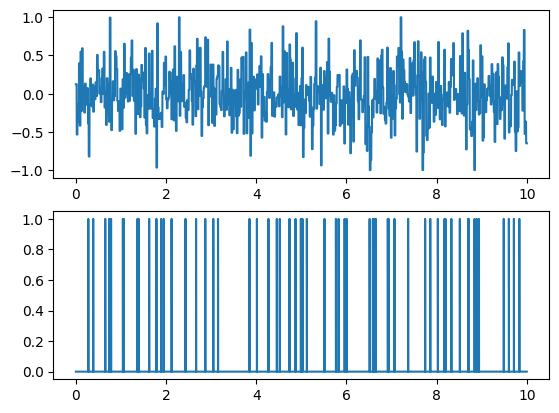

In [8]:
fig, axes = plt.subplots(2,1)
trial =0
t_ms = np.arange(stimulus.shape[1])*dt
axes[0].plot(t_ms, stimulus[trial,:])
axes[1].plot(t_ms, spk_train[trial,:])

# Design design matrix X_full = [B,T,D]

In [9]:
nLinearRFs = 10 #;     %number of stimulus basis functions
numShortSHFilts = 5#; %each is 0.4ms long - used for refractory period
nSHfilters = 7+numShortSHFilts#;%7+

nInh = 1#;
nExc = 1#

RFstart = 2e-3 #;%0?
RFend   = 150e-3#;%150e-3 or 180e-3;
b = 0.02
t, B_orth, B_raw = makeRaisedCosBasis(nLinearRFs, dt, [RFstart, RFend], b, zflag=0)
B_orth.shape

(2478, 10)

In [11]:
stimulus_t = torch.as_tensor(stimulus, dtype=torch.float64, device=device)
B_orth_t   = torch.as_tensor(B_orth,   dtype=torch.float64, device=device)
stimulus_t.shape, B_orth_t.shape

(torch.Size([5, 100000]), torch.Size([2478, 10]))

In [12]:
# stimulus_t: [B, T]
# basis_t: [L, P]
X_trials = [
    convolveStimulusWithBasis_torch(stimulus_t[b], B_orth_t, add_ones=True)  # -> [T, P+1]
    for b in range(stimulus_t.shape[0])
]
# len(X_trials)=11, each X_trials[b] is [99853, P+1]
X_full = torch.stack(X_trials, dim=0)  # [B,T,D]
X_full.shape

torch.Size([5, 100000, 11])

In [13]:
import torch
import torch.nn.functional as F

# ----------------------------
# 1) Helper: build spike-bin indices from a 0/1 vector (or counts) y[t]
# ----------------------------
def spike_bins_from_y(y: torch.Tensor):
    """
    y: [T] or [T,1] with 0/1 (or >=1) spikes per bin
    returns: 1D long tensor of indices where y>0
    """
    if y.ndim == 2:
        y = y[:, 0]
    return torch.where(y > 0)[0].to(torch.long)


# ----------------------------
# 2) Trial-based training loop
# ----------------------------
def train_cbem_trials(
    model,
    X_cond: torch.Tensor,                # [B, T, D]
    spkTimes_bins: list[torch.Tensor],   # len B, each tensor is 1D spike-bin indices
    *,
    lr=1e-2,
    weight_decay=0.0,
    conductance_penalty=(1.0, 0.2),
    n_steps=2000,
    print_every=100,
    clip_grad_norm=1.0,
    window_size=None,
    seed=0,
):
    torch.manual_seed(seed)
    device = X_cond.device

    if X_cond.ndim != 3:
        raise ValueError(f"X_cond must be [B,T,D], got shape {tuple(X_cond.shape)}")

    B, T, D = X_cond.shape
    if len(spkTimes_bins) != B:
        raise ValueError(f"len(spkTimes_bins)={len(spkTimes_bins)} must match B={B}")

    # Ensure parameters exist (B_cond is lazy)
    with torch.no_grad():
        _ = model(X_cond[0, :10, :])

    print(f"Model parameters on device: {next(model.parameters()).device}")
    print(f"Input data (X_cond) on device: {X_cond.device}")

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    loss_vals = []
    history_steps = []

    for step in range(1, n_steps + 1):
        model.train()
        opt.zero_grad(set_to_none=True)

        total_loss = torch.zeros((), device=device, dtype=X_cond.dtype)
        total_bins = 0

        for b in range(B):
            if window_size is None:
                window = None
                spk_local = spkTimes_bins[b]
                bins_used = T
            else:
                W = min(int(window_size), T)
                start = torch.randint(low=0, high=max(1, T - W + 1), size=(1,), device=device).item()
                window = torch.arange(start, start + W, device=device, dtype=torch.long)

                spk_b = spkTimes_bins[b]
                spk_local = spk_b[(spk_b >= start) & (spk_b < start + W)] - start
                bins_used = W

            loss_b = cbem_penalized_nll(
                model=model,
                stimulus=X_cond[b],
                spkTimes_bins=spk_local,
                window=window,
                conductance_penalty=conductance_penalty,
            )
            total_loss = total_loss + loss_b
            total_bins += bins_used

        # Per-bin average over all trials keeps scale stable.
        loss = total_loss / max(1, total_bins)
        loss.backward()

        if clip_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=float(clip_grad_norm))

        opt.step()

        if (step % print_every) == 0 or step == 1:
            model.eval()
            with torch.no_grad():
                mean_rate_hz = 0.0
                mean_p = 0.0
                for b in range(B):
                    rate_b, _ = model(X_cond[b])
                    lam_b = rate_b * model.binsize_s
                    mean_rate_hz += float(rate_b.mean())
                    mean_p += float((-torch.expm1(-lam_b)).mean())
                mean_rate_hz /= B
                mean_p /= B

            loss_vals.append(float(loss.detach().cpu()))
            history_steps.append(step)
            print(
                f"step {step:5d} | loss {float(loss):.6f} | "
                f"mean rate {mean_rate_hz:.3f} Hz | mean p {mean_p:.6f}"
            )

    return model, (history_steps, loss_vals)


model = CBEM(binsize_s=dt).to(device)
trained, (steps_hist, loss_hist) = train_cbem_trials(
    model,
    X_cond=X_full,
    spkTimes_bins=spk_idx_trials,
    lr=3e-2,
    conductance_penalty=(0.01, 0.001),
    n_steps=2000,
    print_every=100,
    clip_grad_norm=1.0,
    window_size=None,
)

# After training, your learned basis weights are:
B_cond_learned = trained.B_cond.detach().cpu()  # [D,2]



Model parameters on device: cuda:0
Input data (X_cond) on device: cuda:0


NameError: name 'cbem_penalized_nll' is not defined